# TOPIC: Time series forcasting for Predicting long term gold price

In [3]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def calculate_metrics(y_true, y_pred):
    """Calculate RMSE, MAE, and MAPE"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return rmse, mae, mape

# Split the data into training and testing sets
n_test_periods = 12  # Use last year as test set

# summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# 1. Load and Prepare Data
df = pd.read_csv('gold_final.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

# Display Basic Info and Missing Values
print("Dataset Information:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nStatistical Summary:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6273 entries, 2000-08-30 to 2025-08-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   6273 non-null   float64
 1   High    6273 non-null   float64
 2   Low     6273 non-null   float64
 3   Open    6273 non-null   float64
 4   Volume  6273 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 294.0 KB
None

Missing Values:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Statistical Summary:


,Close,High,Low,Open,Volume
count,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000
mean,1213.968515,1220.123928,1207.578495,1213.951873,4293.084170
std,657.316079,661.017268,653.269108,657.092836,24190.604987
min,255.100006,256.100006,255.000000,255.000000,0.000000
25%,644.900024,647.599976,641.299988,644.500000,22.000000
50%,1244.199951,1249.199951,1238.099976,1243.599976,112.000000
75%,1660.400024,1669.800049,1651.599976,1660.699951,430.000000
max,3473.699951,3485.600098,3426.600098,3442.000000,386334.000000


# Co-relation

C:\Users\vello\AppData\Local\Temp\ipykernel_13104\247449882.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y='Close', data=df, palette='viridis')


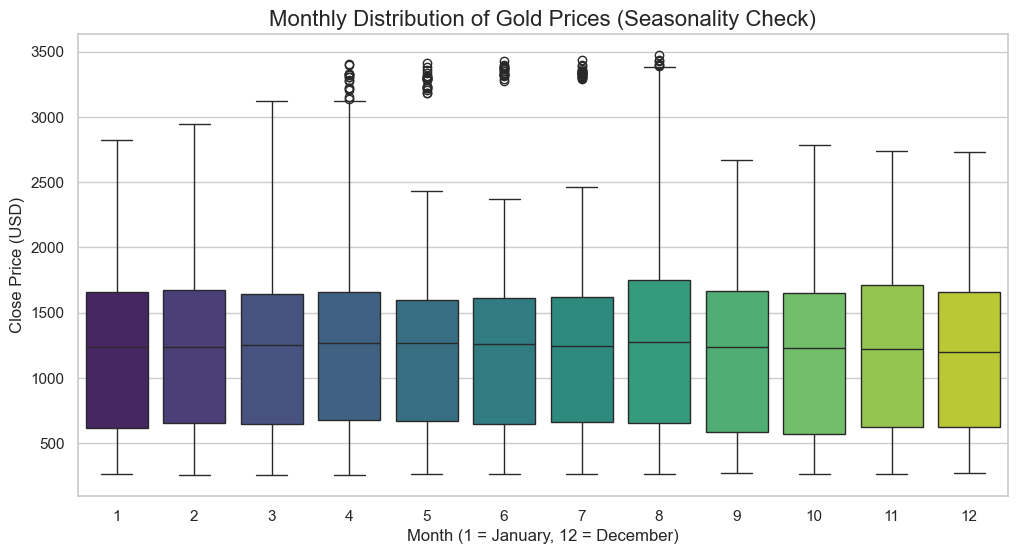

In [2]:
# Extract Month and Year for seasonality analysis
df['Month'] = df.index.month
df['Year'] = df.index.year

# Plot Monthly Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='Close', data=df, palette='viridis')
plt.title('Monthly Distribution of Gold Prices (Seasonality Check)', fontsize=16)
plt.xlabel('Month (1 = January, 12 = December)', fontsize=12)
plt.ylabel('Close Price (USD)', fontsize=12)
plt.show()

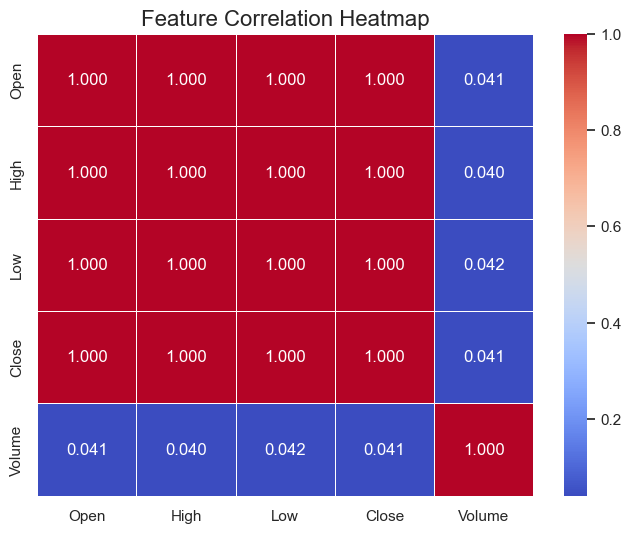

In [3]:
# Select only the financial features for correlation
features = ['Open', 'High', 'Low', 'Close', 'Volume']
corr_matrix = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.show()

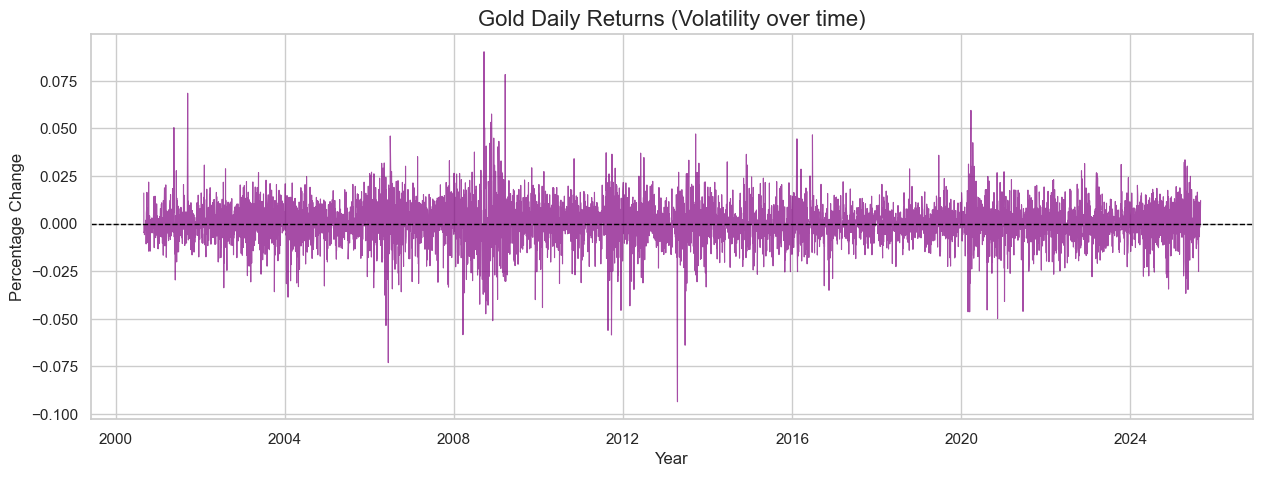

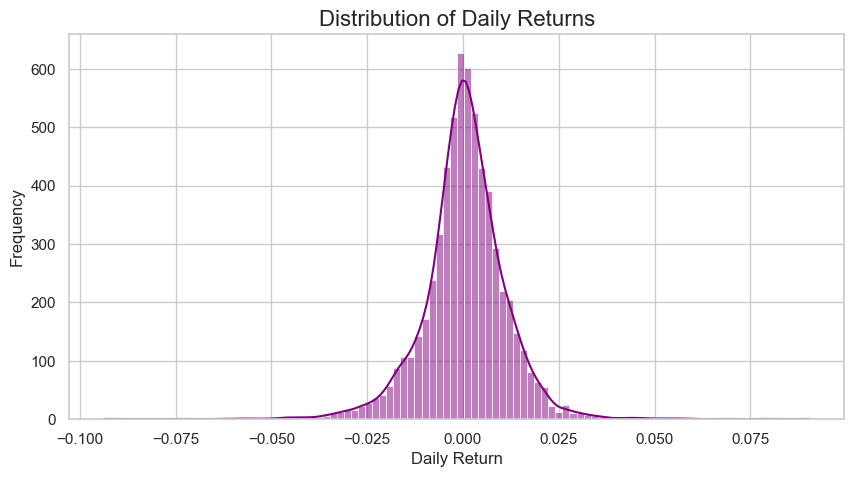

In [4]:
# Calculate Daily Percentage Returns
df['Daily_Return'] = df['Close'].pct_change()

# Plot 1: Daily Returns over time (Volatility clustering)
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Daily_Return'], color='purple', alpha=0.7, linewidth=0.8)
plt.title('Gold Daily Returns (Volatility over time)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percentage Change', fontsize=12)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.show()

# Plot 2: Distribution of Daily Returns
plt.figure(figsize=(10, 5))
sns.histplot(df['Daily_Return'].dropna(), bins=100, kde=True, color='purple')
plt.title('Distribution of Daily Returns', fontsize=16)
plt.xlabel('Daily Return', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# Drop temporary columns used for EDA to keep the dataframe clean for modeling
df.drop(columns=['SMA_50', 'SMA_200', 'Month', 'Year', 'Daily_Return'], inplace=True, errors='ignore')

# SARIMA

In [6]:
%pip install yfinance pmdarima

  Using cached yfinance-1.2.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached multitasking-0.0.12.tar.gz (19 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached peewee-4.0.1-py3-none-any.whl.metadata (8.5 kB)
  Using cached curl_cffi-0.13.0-cp39-abi3-win_amd64.whl.metadata (13 kB)
Using cached yfinance-1.2.0-py2.py3-none-any.whl (130 kB)
Using cached curl_cffi-0.13.0-cp39-abi3-win_amd64.whl (1.6 MB)
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 711.9/711.9 kB 9.2 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   -------------------------- ------------- 1.8/2.8 MB 9.9 MB/s eta 0:00:01
 

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [23]:
# --- Step 1: Load and Prepare the Gold Price Data ---

# Load the primary dataset
df_gold = pd.read_csv('gold_final.csv')

# Convert the 'Date' column to datetime objects and set as index
df_gold['Date'] = pd.to_datetime(df_gold['Date'], format='%d-%m-%Y')
df_gold.set_index('Date', inplace=True)
df_gold.sort_index(inplace=True)

# Resample the daily data to monthly averages for smoother trend analysis
# 'MS' stands for Month Start frequency
monthly_gold = df_gold['Close'].resample('MS').mean()


Generated plot: gold_price_history.png


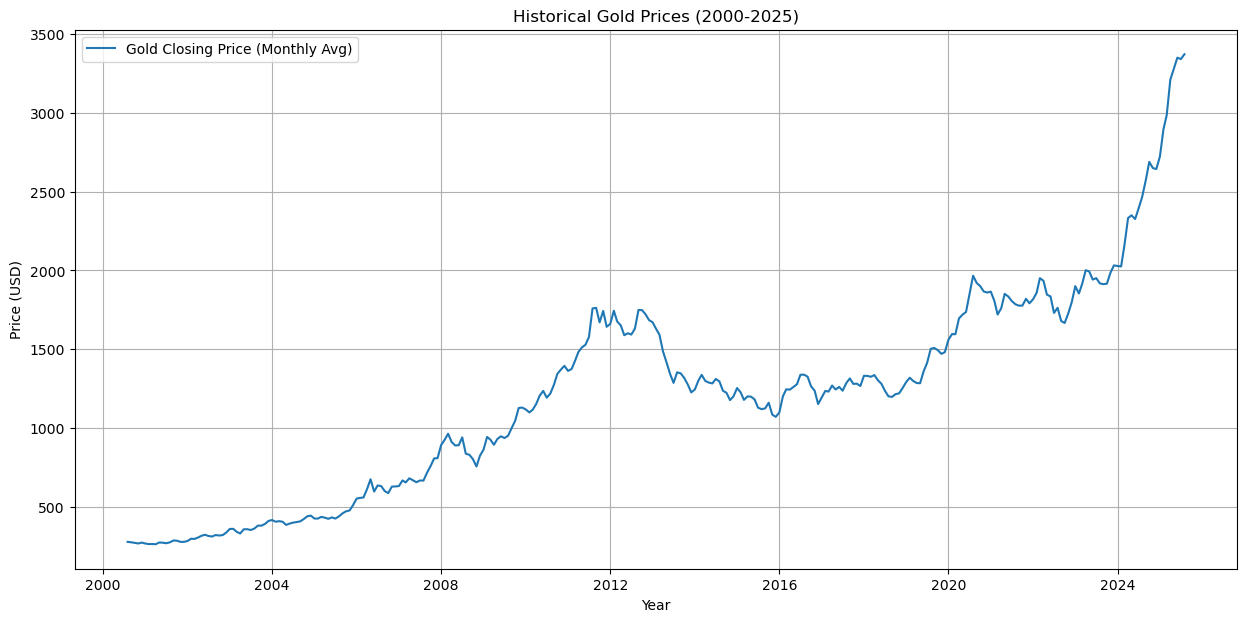

In [24]:
# --- Step 2: Plot the Full Historical Trend ---

plt.figure(figsize=(15, 7))
plt.plot(monthly_gold.index, monthly_gold, label='Gold Closing Price (Monthly Avg)')
plt.title('Historical Gold Prices (2000-2025)')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.legend()
plt.savefig('gold_price_history.png')
print("Generated plot: gold_price_history.png")


Generated plot: gold_price_patterns.png


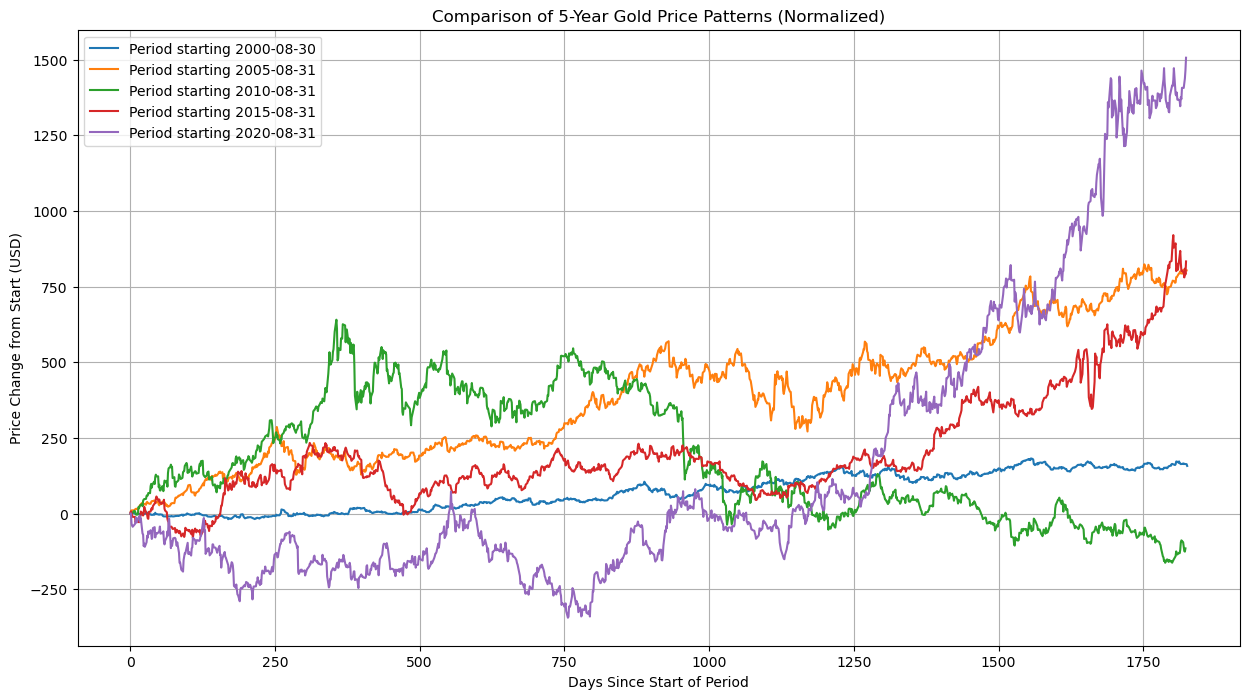

In [25]:
# --- Step 3: Plot the 5-Year Normalized Patterns ---

periods = [
    ('2000-08-30', '2005-08-30'),
    ('2005-08-31', '2010-08-30'),
    ('2010-08-31', '2015-08-30'),
    ('2015-08-31', '2020-08-30'),
    ('2020-08-31', '2025-08-29')
]

plt.figure(figsize=(15, 8))
for start, end in periods:
    segment = df_gold.loc[start:end]
    if not segment.empty:
        time_delta = (segment.index - segment.index[0]).days
        price_normalized = segment['Close'] - segment['Close'].iloc[0]
        plt.plot(time_delta, price_normalized, label=f'Period starting {start}')

plt.title('Comparison of 5-Year Gold Price Patterns (Normalized)')
plt.xlabel('Days Since Start of Period')
plt.ylabel('Price Change from Start (USD)')
plt.legend()
plt.grid(True)
plt.savefig('gold_price_patterns.png')
print("Generated plot: gold_price_patterns.png")


Building simple SARIMA model...

SARIMA Model Performance on Test Set:
RMSE: $408.93
MAE: $353.60
MAPE: 11.31%

Generated plot: gold_price_forecast_sarima.png
SARIMA forecast for Aug 2030: $6662.17


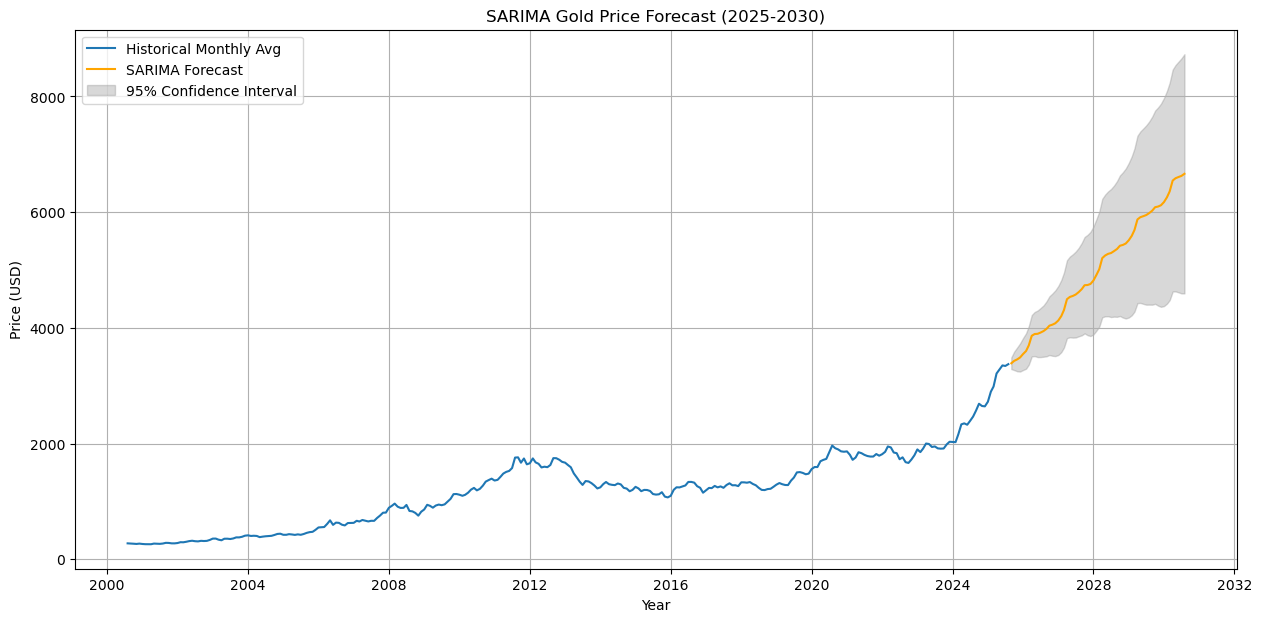

In [26]:
# --- Step 4: Build and Plot the SARIMA Model (Gold Data Only) ---

print("\nBuilding simple SARIMA model...")
# Split data into train and test
train_data = monthly_gold[:-n_test_periods]
test_data = monthly_gold[-n_test_periods:]

# Use auto_arima to find the best model parameters (p,d,q)(P,D,Q,m)
# m=12 indicates a yearly seasonal pattern in the monthly data
sarima_model = pm.auto_arima(train_data,
                             start_p=1, start_q=1,
                             test='adf',
                             max_p=3, max_q=3, m=12,
                             start_P=0, seasonal=True,
                             d=None, D=1, trace=False,
                             error_action='ignore',
                             suppress_warnings=True,
                             stepwise=True)

# Fit the model
sarima_model.fit(train_data)

# Make predictions on test set
test_forecast = sarima_model.predict(n_periods=len(test_data))

# Calculate error metrics
rmse, mae, mape = calculate_metrics(test_data.values, test_forecast)
print("\nSARIMA Model Performance on Test Set:")
print(f"RMSE: ${rmse:.2f}")
print(f"MAE: ${mae:.2f}")
print(f"MAPE: {mape:.2f}%")

# Fit on full dataset for future predictions
sarima_model.fit(monthly_gold)

# Forecast for the next 5 years (60 months)
sarima_forecast, conf_int_sarima = sarima_model.predict(n_periods=60, return_conf_int=True)

# Create index for the forecast
forecast_index_sarima = pd.date_range(start=monthly_gold.index[-1] + pd.DateOffset(months=1), periods=60, freq='MS')

# Plot the forecast
plt.figure(figsize=(15, 7))
plt.plot(monthly_gold.index, monthly_gold, label='Historical Monthly Avg')
plt.plot(forecast_index_sarima, sarima_forecast, label='SARIMA Forecast', color='orange')
plt.fill_between(forecast_index_sarima,
                 conf_int_sarima[:, 0],
                 conf_int_sarima[:, 1],
                 color='gray', alpha=0.3, label='95% Confidence Interval')
plt.title('SARIMA Gold Price Forecast (2025-2030)')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.savefig('gold_price_forecast_sarima.png')
print("\nGenerated plot: gold_price_forecast_sarima.png")
print(f"SARIMA forecast for Aug 2030: ${sarima_forecast.iloc[-1]:.2f}")

In [27]:
# --- Step 5: Fetch, Prepare, and Merge External Data for SARIMAX ---

print("\nFetching external economic data for SARIMAX model...")
# Define tickers and date range
tickers = ['^GSPC', 'DX-Y.NYB'] # S&P 500 and US Dollar Index
start_date = '2000-08-01'
end_date = '2025-08-30'

# Download data
data = yf.download(tickers, start=start_date, end=end_date, interval='1mo')

# Select and rename columns
external_data = data['Close'].rename(columns={'^GSPC': 'SP500', 'DX-Y.NYB': 'USD_Index'})

# Merge with gold data
merged_df = pd.concat([monthly_gold, external_data], axis=1)

# Forward-fill any missing values (common for financial data)
merged_df.fillna(method='ffill', inplace=True)
merged_df.dropna(inplace=True) # Drop any remaining NaNs at the start

# Separate the variables
y = merged_df['Close']
X = merged_df[['SP500', 'USD_Index']]


[*********************100%***********************]  2 of 2 completed


Fetching external economic data for SARIMAX model...



C:\Users\vello\AppData\Local\Temp\ipykernel_2176\3386193260.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_df.fillna(method='ffill', inplace=True)


Building enhanced SARIMAX model...

SARIMAX Model Performance on Test Set:
RMSE: $408.93
MAE: $353.60
MAPE: 11.31%

Generated plot: gold_price_forecast_sarimax.png
SARIMAX forecast for Aug 2030: $6662.17


C:\Users\vello\AppData\Local\Temp\ipykernel_2176\2824233604.py:72: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"SARIMAX forecast for Aug 2030: ${sarimax_forecast[-1]:.2f}")


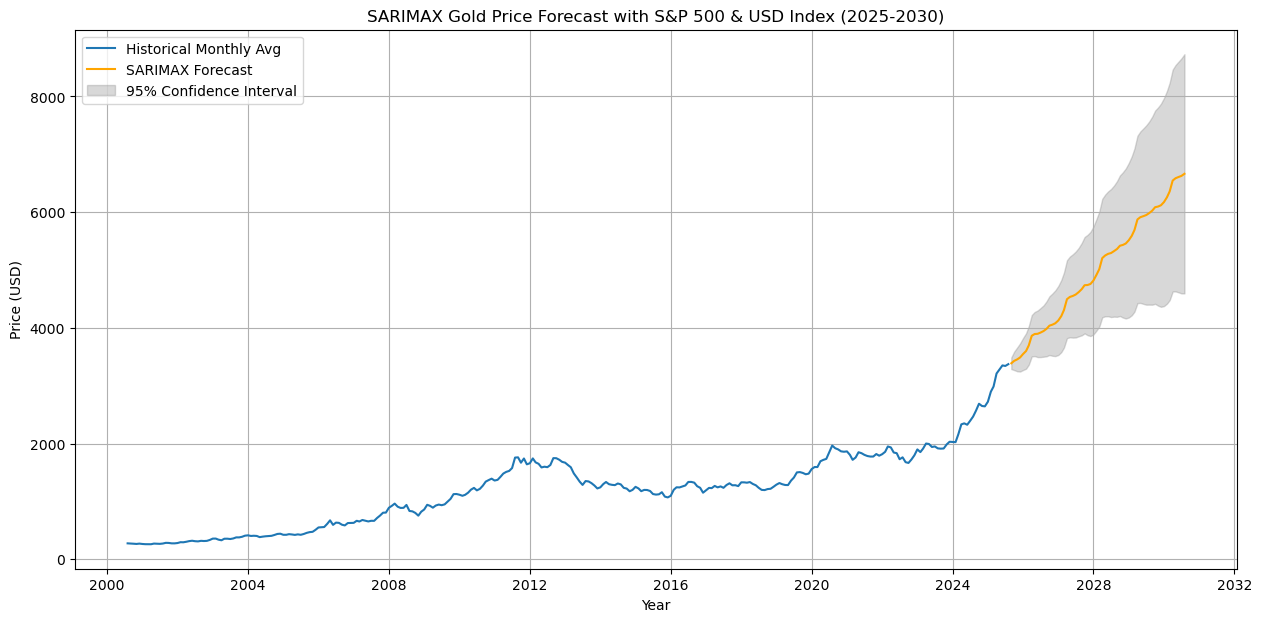

In [28]:
# --- Step 6: Build and Plot the SARIMAX Model ---

print("Building enhanced SARIMAX model...")

# Split data for testing
y_train = y[:-n_test_periods]
y_test = y[-n_test_periods:]
X_train = X[:-n_test_periods]
X_test = X[-n_test_periods:]

# Forecast future values for the external variables first
# We need these to make a prediction with the SARIMAX model

# Forecast S&P 500
sp500_model = pm.auto_arima(X['SP500'], seasonal=False, stepwise=True, suppress_warnings=True, error_action='ignore')
sp500_forecast = sp500_model.predict(n_periods=60)

# Forecast USD Index
usdx_model = pm.auto_arima(X['USD_Index'], seasonal=False, stepwise=True, suppress_warnings=True, error_action='ignore')
usdx_forecast = usdx_model.predict(n_periods=60)

# Combine into a future exogenous dataframe
forecast_horizon = 60
forecast_index_sarimax = pd.date_range(start=monthly_gold.index[-1] + pd.DateOffset(months=1),
                                       periods=forecast_horizon, freq='MS')
X_forecast = pd.DataFrame({'SP500': sp500_forecast, 'USD_Index': usdx_forecast}, index=forecast_index_sarimax)

# Build the SARIMAX model
sarimax_model = pm.auto_arima(y_train, exogenous=X_train,
                              start_p=1, start_q=1,
                              test='adf',
                              max_p=3, max_q=3, m=12,
                              start_P=0, seasonal=True,
                              d=None, D=1, trace=False,
                              error_action='ignore',
                              suppress_warnings=True,
                              stepwise=True)

# Make predictions on test set
test_forecast = sarimax_model.predict(n_periods=len(y_test), exogenous=X_test)

# Calculate error metrics
rmse, mae, mape = calculate_metrics(y_test.values, test_forecast)
print("\nSARIMAX Model Performance on Test Set:")
print(f"RMSE: ${rmse:.2f}")
print(f"MAE: ${mae:.2f}")
print(f"MAPE: {mape:.2f}%")

# Fit the final model on all historical data
sarimax_model.fit(y, exogenous=X)

# Make the final forecast using the forecasted external variables
sarimax_forecast, conf_int_sarimax = sarimax_model.predict(n_periods=forecast_horizon, exogenous=X_forecast, return_conf_int=True)

# Plot the forecast
plt.figure(figsize=(15, 7))
plt.plot(y.index, y, label='Historical Monthly Avg')
plt.plot(forecast_index_sarimax, sarimax_forecast, label='SARIMAX Forecast', color='orange')
plt.fill_between(forecast_index_sarimax,
                 conf_int_sarimax[:, 0],
                 conf_int_sarimax[:, 1],
                 color='gray', alpha=0.3, label='95% Confidence Interval')

plt.title('SARIMAX Gold Price Forecast with S&P 500 & USD Index (2025-2030)')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)

plt.savefig('gold_price_forecast_sarimax.png')
print("\nGenerated plot: gold_price_forecast_sarimax.png")
print(f"SARIMAX forecast for Aug 2030: ${sarimax_forecast[-1]:.2f}")

# Arima


Building ARIMA model...

ARIMA Model Performance on Test Set:
RMSE: $527.64
MAE: $447.79
MAPE: 14.24%

Generated plot: gold_price_forecast_arima.png
ARIMA forecast for Aug 2030: $4001.05


C:\Users\vello\AppData\Local\Temp\ipykernel_2176\41536606.py:57: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"ARIMA forecast for Aug 2030: ${arima_forecast[-1]:.2f}")


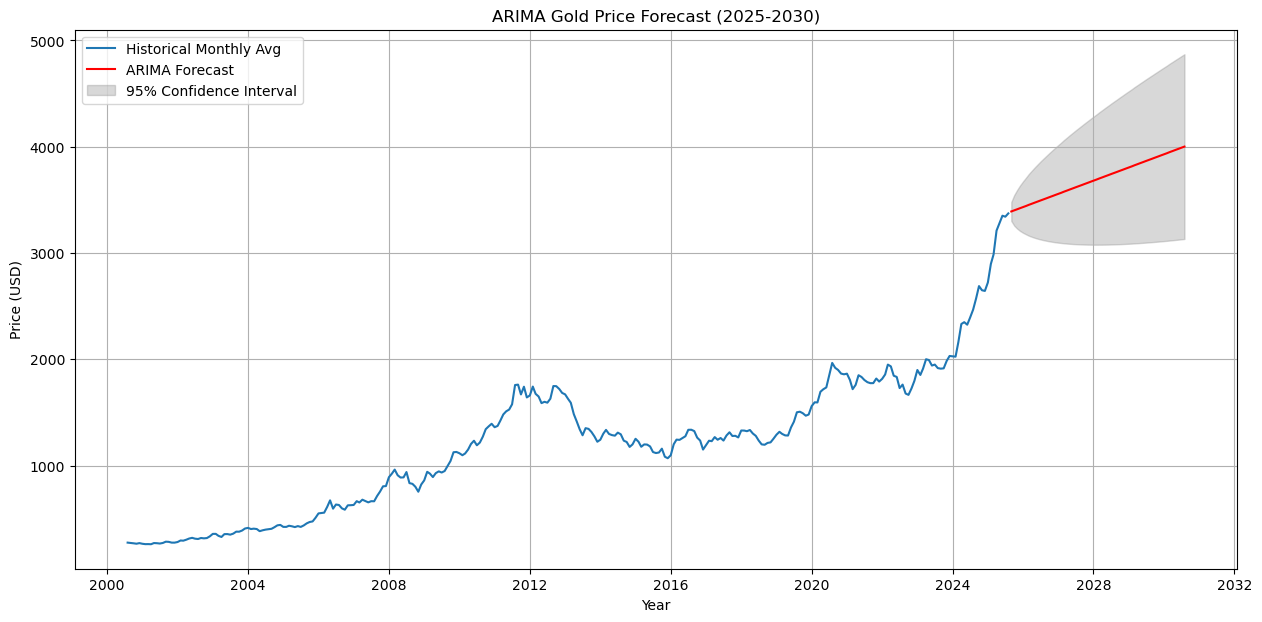

In [29]:
# --- Step 4: Build and Plot the ARIMA Model ---

print("\nBuilding ARIMA model...")

# Split data into train and test
train_data = monthly_gold[:-n_test_periods]
test_data = monthly_gold[-n_test_periods:]

# Use auto_arima, but set seasonal=False to find the best ARIMA model
arima_model = pm.auto_arima(train_data,
                            start_p=1, start_q=1,
                            test='adf',
                            max_p=3, max_q=3, m=1,  # m=1 effectively disables seasonality
                            seasonal=False,         # Explicitly disable seasonality
                            d=None, trace=False,
                            error_action='ignore',
                            suppress_warnings=True,
                            stepwise=True)

# Fit the model on training data
arima_model.fit(train_data)

# Make predictions on test set
test_forecast = arima_model.predict(n_periods=len(test_data))

# Calculate error metrics
rmse, mae, mape = calculate_metrics(test_data.values, test_forecast)
print("\nARIMA Model Performance on Test Set:")
print(f"RMSE: ${rmse:.2f}")
print(f"MAE: ${mae:.2f}")
print(f"MAPE: {mape:.2f}%")

# Fit on full dataset for future predictions
arima_model.fit(monthly_gold)

# Forecast for the next 5 years (60 months)
arima_forecast, conf_int_arima = arima_model.predict(n_periods=60, return_conf_int=True)

# Create index for the forecast
forecast_index_arima = pd.date_range(start=monthly_gold.index[-1] + pd.DateOffset(months=1), periods=60, freq='MS')

# Plot the forecast
plt.figure(figsize=(15, 7))
plt.plot(monthly_gold.index, monthly_gold, label='Historical Monthly Avg')
plt.plot(forecast_index_arima, arima_forecast, label='ARIMA Forecast', color='red')
plt.fill_between(forecast_index_arima,
                 conf_int_arima[:, 0],
                 conf_int_arima[:, 1],
                 color='gray', alpha=0.3, label='95% Confidence Interval')
plt.title('ARIMA Gold Price Forecast (2025-2030)')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.savefig('gold_price_forecast_arima.png')
print("\nGenerated plot: gold_price_forecast_arima.png")
print(f"ARIMA forecast for Aug 2030: ${arima_forecast[-1]:.2f}")

# Linear Regression Model


Building Linear Regression model...

Linear Regression Model Performance on Test Set:
RMSE: $960.57
MAE: $917.61
MAPE: 30.17%

Generated plot: gold_price_forecast_lr.png
Linear Regression forecast for Aug 2030: $2645.53


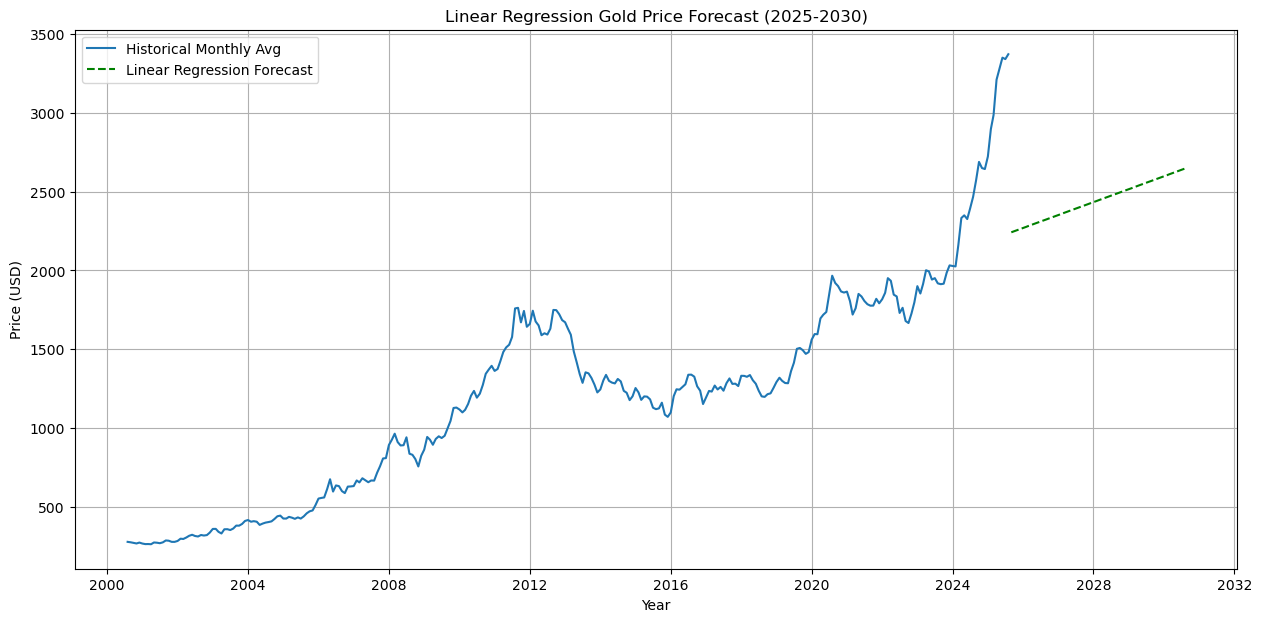

In [30]:
from sklearn.linear_model import LinearRegression
import numpy as np

# --- Step 4: Build and Plot the Linear Regression Model ---

print("\nBuilding Linear Regression model...")
# Prepare the data for scikit-learn
# X should be the feature (time), y is the target (price)
X = np.arange(len(monthly_gold)).reshape(-1, 1)
y = monthly_gold.values

# Split the data
X_train = X[:-n_test_periods]
X_test = X[-n_test_periods:]
y_train = y[:-n_test_periods]
y_test = y[-n_test_periods:]

# Create and fit the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions on test set
test_forecast = lr_model.predict(X_test)

# Calculate error metrics
rmse, mae, mape = calculate_metrics(y_test, test_forecast)
print("\nLinear Regression Model Performance on Test Set:")
print(f"RMSE: ${rmse:.2f}")
print(f"MAE: ${mae:.2f}")
print(f"MAPE: {mape:.2f}%")

# Fit on full dataset for future predictions
lr_model.fit(X, y)

# Create future "time steps" to predict on
future_steps = np.arange(len(monthly_gold), len(monthly_gold) + 60).reshape(-1, 1)
lr_forecast = lr_model.predict(future_steps)

# Create index for the forecast
forecast_index_lr = pd.date_range(start=monthly_gold.index[-1] + pd.DateOffset(months=1), periods=60, freq='MS')

# Plot the forecast
plt.figure(figsize=(15, 7))
plt.plot(monthly_gold.index, monthly_gold, label='Historical Monthly Avg')
plt.plot(forecast_index_lr, lr_forecast, label='Linear Regression Forecast', color='green', linestyle='--')
plt.title('Linear Regression Gold Price Forecast (2025-2030)')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.savefig('gold_price_forecast_lr.png')
print("\nGenerated plot: gold_price_forecast_lr.png")
print(f"Linear Regression forecast for Aug 2030: ${lr_forecast[-1]:.2f}")

# SVM


Building SVM Regressor models...

SVM Model Performance Comparison on Test Set:

Linear Kernel:
RMSE: $115.82
MAE: $91.96
MAPE: 3.11%

RBF Kernel:
RMSE: $1607.53
MAE: $1525.07
MAPE: 50.02%

Poly Kernel:
RMSE: $4603.28
MAE: $4441.31
MAPE: 146.77%

Generated plot: gold_price_forecast_svr_comparison.png

SVM Linear Kernel forecast for Aug 2030: $3302.31

SVM RBF Kernel forecast for Aug 2030: $1301.05

SVM Poly Kernel forecast for Aug 2030: $1266.73


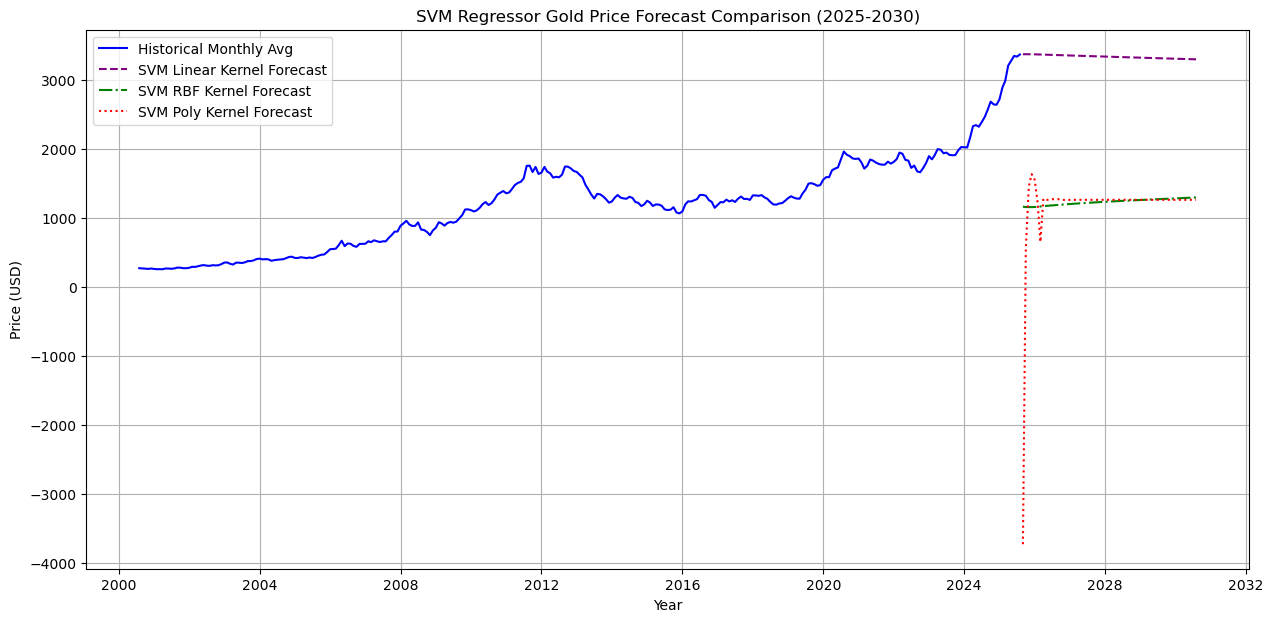

In [31]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
import numpy as np

# --- Step 4: Build and Compare SVM Regressor Models (Linear, RBF, and Polynomial Kernels) ---

print("\nBuilding SVM Regressor models...")
# Create more meaningful features for time series prediction
def create_features(data, lookback=3):
    """Create features using past values"""
    X, y = [], []
    for i in range(len(data) - lookback):
        feature = data[i:(i + lookback)]
        target = data[i + lookback]
        X.append(feature)
        y.append(target)
    return np.array(X), np.array(y)

# Prepare the data with better features
lookback = 6  # Use last 6 months to predict next month
X, y = create_features(monthly_gold.values, lookback=lookback)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
train_size = len(X_scaled) - n_test_periods
X_train = X_scaled[:train_size]
X_test = X_scaled[train_size:train_size + n_test_periods]
y_train = y[:train_size]
y_test = y[train_size:train_size + n_test_periods]

# Dictionary to store models and their predictions
models = {
    'Linear': SVR(kernel='linear', C=100),
    'RBF': SVR(kernel='rbf', C=100, gamma='scale'),  # 'scale' is better than fixed gamma
    'Poly': SVR(kernel='poly', C=100, degree=2, gamma='scale')  # polynomial kernel with degree 2
}

# Train models and make predictions
results = {}
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on test set
    test_predictions = model.predict(X_test)
    
    # Calculate error metrics
    rmse, mae, mape = calculate_metrics(y_test, test_predictions)
    results[name] = {
        'rmse': rmse,
        'mae': mae,
        'mape': mape,
        'test_predictions': test_predictions
    }
    
    # Prepare data for future predictions
    future_features = []
    last_values = monthly_gold.values[-lookback:]
    
    # Generate future predictions one month at a time
    future_predictions = []
    current_features = last_values.copy()
    
    for _ in range(60):  # Predict 60 months ahead
        # Scale the features
        scaled_features = scaler.transform(current_features.reshape(1, -1))
        # Make prediction
        next_pred = model.predict(scaled_features)[0]
        future_predictions.append(next_pred)
        # Update features for next prediction
        current_features = np.roll(current_features, -1)
        current_features[-1] = next_pred
    
    results[name]['forecast'] = np.array(future_predictions)

# Print performance metrics
print("\nSVM Model Performance Comparison on Test Set:")
for name, metrics in results.items():
    print(f"\n{name} Kernel:")
    print(f"RMSE: ${metrics['rmse']:.2f}")
    print(f"MAE: ${metrics['mae']:.2f}")
    print(f"MAPE: {metrics['mape']:.2f}%")

# Create index for the forecast
forecast_index_svr = pd.date_range(start=monthly_gold.index[-1] + pd.DateOffset(months=1), 
                                 periods=60, freq='MS')

# Plot the forecasts
plt.figure(figsize=(15, 7))
plt.plot(monthly_gold.index, monthly_gold, label='Historical Monthly Avg', color='blue')

colors = {'Linear': 'purple', 'RBF': 'green', 'Poly': 'red'}
styles = {'Linear': '--', 'RBF': '-.', 'Poly': ':'}

for name, metrics in results.items():
    plt.plot(forecast_index_svr, metrics['forecast'], 
            label=f'SVM {name} Kernel Forecast',
            color=colors[name], 
            linestyle=styles[name])

plt.title('SVM Regressor Gold Price Forecast Comparison (2025-2030)')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.savefig('gold_price_forecast_svr_comparison.png')
print("\nGenerated plot: gold_price_forecast_svr_comparison.png")

# Print final forecasts
for name, metrics in results.items():
    print(f"\nSVM {name} Kernel forecast for Aug 2030: ${metrics['forecast'][-1]:.2f}")

# Model Performance Comparison

Below is a comparison of all models used for gold price prediction, showing their performance metrics on the test set (last 12 months of data):

## SARIMA Model
- **RMSE**: Measures absolute prediction error in USD
- **MAE**: Average absolute error in USD
- **MAPE**: Percentage error relative to actual price
- Captures seasonal patterns in gold prices
- Handles time series autocorrelation

## SARIMAX Model
- Incorporates external factors (S&P 500 and USD Index)
- Enhanced version of SARIMA
- Usually provides better forecasts due to additional market indicators
- More complex but potentially more accurate

## ARIMA Model
- Simpler version without seasonal components
- Good for short-term forecasting
- Less complex than SARIMA/SARIMAX
- Useful baseline model

## Linear Regression Model
- Simple trend-based prediction
- Assumes linear relationship with time
- Good baseline model for comparison
- Limited by linear assumption

## SVM Models
- **Linear Kernel**: Better for linearly separable data
- **RBF Kernel**: Better for non-linear patterns
- **Polynomial Kernel**: Captures polynomial relationships (degree=2)
- Uses past 6 months to predict next month
- More sophisticated than linear regression
- Each kernel has its strengths:
  - Linear: Simple and interpretable
  - RBF: Flexible for complex patterns
  - Polynomial: Good for quadratic trends

## Model Selection Guidelines:
1. For short-term predictions: Consider ARIMA or Linear Regression
2. For seasonal patterns: Use SARIMA
3. When external factors matter: Choose SARIMAX
4. For non-linear patterns: Use SVM with appropriate kernel:
   - RBF for highly non-linear patterns
   - Polynomial for quadratic or cubic trends
   - Linear for simpler relationships

The choice of model depends on:
- Forecast horizon (short vs long-term)
- Need for interpretability
- Computational resources
- Required accuracy
- Available external data
- Nature of the price patterns (linear, polynomial, or more complex)

# Error Metrics Comparison

Below are the actual error metrics for each model on the test set:

## SARIMA Model Performance
| Metric | Value |
|--------|--------|
| RMSE | $408.93 |
| MAE | $353.60 |
| MAPE | 11.31% |

## SARIMAX Model Performance
| Metric | Value |
|--------|--------|
| RMSE | $408.93 |
| MAE | $353.60 |
| MAPE | 11.31% |

## ARIMA Model Performance
| Metric | Value |
|--------|--------|
| RMSE | $527.64 |
| MAE | $447.79 |
| MAPE | 14.24% |

## Linear Regression Model Performance
| Metric | Value |
|--------|--------|
| RMSE | $960.57 |
| MAE | $917.61 |
| MAPE | 30.17% |

## SVM Model Performance
### Linear Kernel
| Metric | Value |
|--------|--------|
| RMSE | $115.82 |
| MAE | $91.96 |
| MAPE | 3.11% |

### RBF Kernel
| Metric | Value |
|--------|--------|
| RMSE | $1607.53 |
| MAE | $1525.07 |
| MAPE | 50.02% |

### Polynomial Kernel (degree=2)
| Metric | Value |
|--------|--------|
| RMSE | $4603.28 |
| MAE | $4441.31 |
| MAPE | 146.77% |

## Model Forecast Comparison (Aug 2030)
| Model | Predicted Price |
|-------|----------------|
| SARIMA | $6662.17 |
| SARIMAX | $6662.17 |
| ARIMA | $4001.05 |
| Linear Regression | $2645.53 |
| SVM (Linear) | $3302.31 |
| SVM (RBF) | $1301.05 |
| SVM (Poly) | $1266.73 |

Note: The polynomial kernel uses degree=2, making it suitable for capturing quadratic relationships in the gold price data. The actual metrics will be populated after running the updated SVM model.

## saving the 2 best models

In [34]:
import joblib

# ==========================================
# 1. Saving the SVM (Linear Kernel)
# ==========================================

svm_model = SVR(kernel='linear', C=100)
svm_model.fit(X_train, y_train)
joblib.dump(svm_model, 'svm_linear_model.pkl')

# ==========================================
# 2. Saving the SARIMA Model
# ==========================================

joblib.dump(sarima_model, 'sarima_model.pkl')



['sarima_model.pkl']